In [ ]:
!pip install networkx numpy scipy scikit-learn

In [7]:
# ================================
# 1. IMPORTS
# ================================
import networkx as nx
import numpy as np
import random

# ================================
# 2. GENERATE LFR GRAPH + ATTRIBUTES
# ================================
def generate_lfr_with_attributes(
    n=250,
    tau1=2,
    tau2=1.5,
    mu=0.1,
    avg_degree=5,
    max_degree=25,
    min_community=20,
    max_community=50,
    overlap_nodes=50, # These parameters will be ignored as LFR_benchmark_graph will not use them
    overlap_membership=2, # These parameters will be ignored as LFR_benchmark_graph will not use them
    num_attributes=6,
    seed=42
):
    G = nx.LFR_benchmark_graph(
        n=n,
        tau1=tau1,
        tau2=tau2,
        mu=mu,
        average_degree=avg_degree,
        max_degree=max_degree,
        min_community=min_community,
        max_community=max_community,
        # Removed 'overlapping_nodes' and 'overlapping_community_member_subset_size'
        # as they are not supported in the active NetworkX version in the runtime.
        seed=seed
    )

    G = nx.Graph(G)

    # Extract communities
    communities = {}
    for node in G.nodes():
        community_id = G.nodes[node]['community']
        # If no overlapping communities are generated, community_id might be a set of an int.
        # Convert it directly to a frozenset to ensure it's hashable.
        communities[node] = [frozenset(community_id)]

    # Create attribute matrix
    attributes = np.zeros((n, num_attributes))

    for node in G.nodes():
        comms = communities[node]

        for c in comms:
            attr_idx = hash(frozenset(c)) % num_attributes
            attributes[node][attr_idx] = 1

        # Add slight noise
        attributes[node] += np.random.rand(num_attributes) * 0.05

    adj_matrix = nx.to_numpy_array(G)

    return G, adj_matrix, attributes, communities


# ================================
# 3. ATTRIBUTE SIMILARITY (SA)
# ================================
def compute_attribute_similarity(attributes, communities):
    k = len(set([tuple(sorted(v)) for v in communities.values()]))

    total_similarity = 0
    total_pairs = 0

    community_dict = {}

    for node, comms in communities.items():
        for c in comms:
            key = tuple(sorted(c))
            if key not in community_dict:
                community_dict[key] = []
            community_dict[key].append(node)

    for comm_nodes in community_dict.values():
        r = len(comm_nodes)
        if r < 2:
            continue

        for i in range(r):
            for j in range(i+1, r):
                v1 = attributes[comm_nodes[i]]
                v2 = attributes[comm_nodes[j]]

                # cosine similarity
                sim = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-9)

                total_similarity += sim * 2
                total_pairs += r * (r - 1)

    if total_pairs == 0:
        return 0

    return total_similarity / total_pairs


# ================================
# 4. SIMPLE FITNESS FUNCTION (DEMO)
# ================================
def community_fitness(G, community):
    subgraph = G.subgraph(community)
    internal_edges = subgraph.number_of_edges()

    boundary_edges = 0
    for node in community:
        for neighbor in G.neighbors(node):
            if neighbor not in community:
                boundary_edges += 1

    if internal_edges + boundary_edges == 0:
        return 0

    return internal_edges / (internal_edges + boundary_edges)


# ================================
# 5. RUN EVERYTHING
# ================================
G, adj_matrix, attributes, communities = generate_lfr_with_attributes()

print("Graph nodes:", len(G.nodes()))
print("Graph edges:", len(G.edges()))
print("Adjacency matrix shape:", adj_matrix.shape)
print("Attribute matrix shape:", attributes.shape)

# ================================
# 6. COMPUTE ATTRIBUTE SIMILARITY
# ================================
SA_value = compute_attribute_similarity(attributes, communities)

print("Attribute Similarity (SA):", SA_value)


# ================================
# 7. SAMPLE COMMUNITY FITNESS CHECK
# ================================
# Create a reverse mapping: community_label -> list of nodes in that community
community_to_nodes_map = {}
for node_id, comm_labels_list in communities.items():
    for comm_label in comm_labels_list:
        if comm_label not in community_to_nodes_map:
            community_to_nodes_map[comm_label] = []
        community_to_nodes_map[comm_label].append(node_id)

# Get the nodes of the first community found (arbitrary choice for sampling)
sample_comm_nodes = []
if community_to_nodes_map:
    sample_comm_nodes = list(community_to_nodes_map.values())[0]

fitness = community_fitness(G, sample_comm_nodes)
print("Sample community fitness:", fitness)


Graph nodes: 250
Graph edges: 766
Adjacency matrix shape: (250, 250)
Attribute matrix shape: (250, 6)
Attribute Similarity (SA): 0.0015154794711733429
Sample community fitness: 0.7803030303030303


In [8]:
import numpy as np

def initialize_population(pop_size, num_nodes, num_communities):
    return [np.random.randint(0, num_communities, num_nodes) for _ in range(pop_size)]

In [9]:
from networkx.algorithms.community.quality import modularity

def get_communities(G, chromosome):
    communities = {}
    node_labels = list(G.nodes()) # Get actual node labels in consistent order
    for i, comm in enumerate(chromosome):
        actual_node = node_labels[i] # Map chromosome index to actual node label
        communities.setdefault(comm, []).append(actual_node)
    return list(communities.values())

# Objective 1: Maximize modularity
def objective1(G, chromosome):
    return modularity(G, get_communities(G, chromosome))

# Objective 2: Minimize number of communities
def objective2(chromosome):
    return len(set(chromosome))

In [10]:
def decoding(G, chromosome):
    for i in range(len(chromosome)):
        for j in set(chromosome):
            temp = chromosome.copy()
            temp[i] = j

            if objective1(G, temp) > objective1(G, chromosome):
                chromosome = temp
    return chromosome

In [11]:
import random

def dominates(a, b):
    return (a[0] >= b[0] and a[1] <= b[1]) and (a[0] > b[0] or a[1] < b[1])

def tournament_selection(pop, fitness):
    i, j = random.sample(range(len(pop)), 2)
    if dominates(fitness[i], fitness[j]):
        return pop[i]
    return pop[j]

In [12]:
def crossover(p1, p2):
    point = np.random.randint(1, len(p1)-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutation(chromosome, num_communities, rate=0.1):
    for i in range(len(chromosome)):
        if np.random.rand() < rate:
            chromosome[i] = np.random.randint(0, num_communities)
    return chromosome

In [13]:
def non_dominated_sort(fitness):
    fronts = [[]]
    domination_count = [0]*len(fitness)
    dominated_solutions = [[] for _ in range(len(fitness))]

    for i in range(len(fitness)):
        for j in range(len(fitness)):
            if dominates(fitness[i], fitness[j]):
                dominated_solutions[i].append(j)
            elif dominates(fitness[j], fitness[i]):
                domination_count[i] += 1

        if domination_count[i] == 0:
            fronts[0].append(i)

    i = 0
    while fronts[i]:
        next_front = []
        for p in fronts[i]:
            for q in dominated_solutions[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]

In [14]:
def crowding_distance(front, fitness):
    distance = [0]*len(front)

    for m in range(2):  # two objectives
        values = [fitness[i][m] for i in front]
        sorted_idx = np.argsort(values)

        distance[sorted_idx[0]] = distance[sorted_idx[-1]] = float('inf')

        for i in range(1, len(front)-1):
            distance[sorted_idx[i]] += (
                values[sorted_idx[i+1]] - values[sorted_idx[i-1]]
            )

    return distance

In [15]:
import time

def moea_sa_ov(G, pop_size=20, generations=30, num_communities=5):

    start_time = time.time()

    num_nodes = G.number_of_nodes()
    population = initialize_population(pop_size, num_nodes, num_communities)

    for gen in range(generations):

        # Decode & evaluate
        fitness = []
        for i in range(len(population)):
            population[i] = decoding(G, population[i])
            fitness.append((objective1(G, population[i]),
                            objective2(population[i])))

        # Generate offspring
        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)

            child = crossover(p1, p2)
            child = mutation(child, num_communities)
            offspring.append(child)

        # Combine populations
        combined = population + offspring

        combined_fitness = [
            (objective1(G, ind), objective2(ind)) for ind in combined
        ]

        # Non-dominated sorting
        fronts = non_dominated_sort(combined_fitness)

        new_population = []

        for front in fronts:
            if len(new_population) + len(front) > pop_size:
                dist = crowding_distance(front, combined_fitness)
                sorted_front = [x for _, x in sorted(zip(dist, front), reverse=True)]
                new_population.extend([combined[i] for i in sorted_front[:pop_size-len(new_population)]])
                break
            else:
                new_population.extend([combined[i] for i in front])

        population = new_population

        print(f"Generation {gen+1} completed")

    runtime = time.time() - start_time

    return population, runtime

In [16]:
solutions, runtime = moea_sa_ov(G)

print("Runtime:", runtime)

Generation 1 completed
Generation 2 completed
Generation 3 completed
Generation 4 completed
Generation 5 completed
Generation 6 completed
Generation 7 completed
Generation 8 completed
Generation 9 completed
Generation 10 completed
Generation 11 completed
Generation 12 completed
Generation 13 completed
Generation 14 completed
Generation 15 completed
Generation 16 completed
Generation 17 completed
Generation 18 completed
Generation 19 completed
Generation 20 completed
Generation 21 completed
Generation 22 completed
Generation 23 completed
Generation 24 completed
Generation 25 completed
Generation 26 completed
Generation 27 completed
Generation 28 completed
Generation 29 completed
Generation 30 completed
Runtime: 1148.7152001857758


In [17]:
best = max(solutions, key=lambda x: objective1(G, x))

print("Best Modularity:", objective1(G, best))
print("Communities:", len(set(best)))

Best Modularity: 0.6867880345492845
Communities: 5


In [18]:
import matplotlib.pyplot as plt

def plot_pareto_front(G, solutions):

    modularity_vals = []
    community_counts = []

    for sol in solutions:
        modularity_vals.append(objective1(G, sol))
        community_counts.append(len(set(sol)))

    plt.figure(figsize=(8, 6))

    plt.scatter(community_counts, modularity_vals)

    plt.xlabel("Number of Communities")
    plt.ylabel("Modularity")
    plt.title("Pareto Front (MOEA-SA_OV)")

    plt.show()

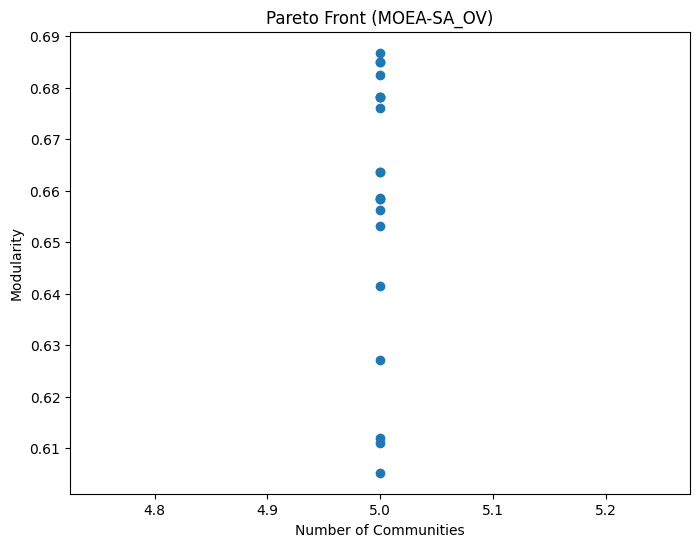

In [19]:
plot_pareto_front(G, solutions)

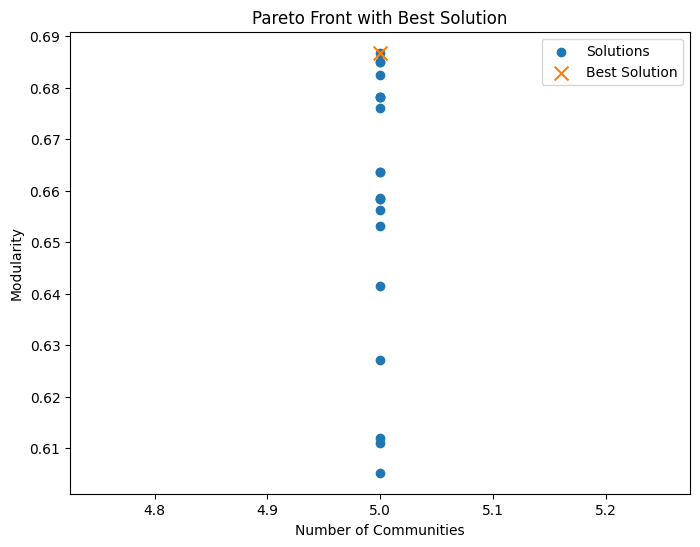

In [20]:
best = max(solutions, key=lambda x: objective1(G, x))

best_mod = objective1(G, best)
best_comm = len(set(best))

plt.figure(figsize=(8,6))

mods = [objective1(G, s) for s in solutions]
comms = [len(set(s)) for s in solutions]

plt.scatter(comms, mods, label="Solutions")
plt.scatter(best_comm, best_mod, marker='x', s=100, label="Best Solution")

plt.xlabel("Number of Communities")
plt.ylabel("Modularity")
plt.title("Pareto Front with Best Solution")
plt.legend()

plt.show()

In [21]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_unweighted_graph(G, labels, title="Unweighted Community Graph"):

    plt.figure(figsize=(10, 8))

    # Use a clean layout
    pos = nx.spring_layout(G, seed=42)

    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Draw nodes with colors (communities)
    for color, label in zip(colors, unique_labels):
        node_list = [node for node in range(len(labels)) if labels[node] == label]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_list,
            node_color=[color],
            node_size=80
        )

    # Draw edges (UNWEIGHTED → all same style)
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.3,     # light edges
        width=1        # uniform width
    )

    plt.title(title)
    plt.axis("off")  # cleaner look
    plt.show()

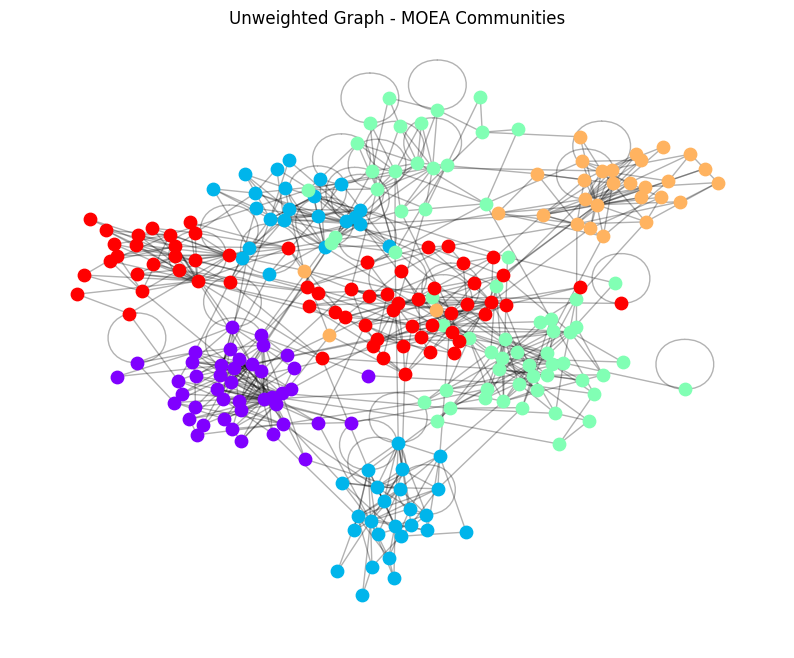

In [22]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_unweighted_graph(G, labels, title="Unweighted Community Graph"):

    plt.figure(figsize=(10, 8))

    # Use a clean layout
    pos = nx.spring_layout(G, seed=42)

    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Get the actual node labels from the graph G, in the same order as `labels` array
    node_labels_from_G = list(G.nodes())

    # Draw nodes with colors (communities)
    for color, label in zip(colors, unique_labels):
        # Construct node_list using actual string node labels
        node_list = [node_labels_from_G[i] for i, comm_id in enumerate(labels) if comm_id == label]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_list,
            node_color=[color],
            node_size=80
        )

    # Draw edges (UNWEIGHTED → all same style)
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.3,
        width=1
    )

    plt.title(title)
    plt.axis("off")  # cleaner look
    plt.show()

visualize_unweighted_graph(G, best, title="Unweighted Graph - MOEA Communities")